In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier,AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score,confusion_matrix,classification_report

In [4]:
conn=sqlite3.connect("/Users/shrey/Great_learning/frieght_cost_classficaion_project/Inventory-Invoice-Analytics/data/inventory.db")
names=pd.read_sql_query("select name from sqlite_master where type='table'",conn)
names

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [6]:
for name in names['name']:
    print("Table:",name)
    display(pd.read_sql_query(f"Select * from {name} limit 5",conn))

Table: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [26]:
pd.read_sql_query("select * from purchases where PONumber=12376",conn)

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,67_EANVERNESS_8621,67,8621,Sho Chiku Bai Takara Sake,750mL,8920,TAKARA SAKE USA INC,12376,2024-09-28,2024-10-06,2024-10-18,2024-11-25,4.59,11,50.49,1
1,6_GOULCREST_20650,6,20650,Sho Chiku Bai Takara Sake,18L,8920,TAKARA SAKE USA INC,12376,2024-09-28,2024-10-05,2024-10-18,2024-11-25,56.03,3,168.09,2
2,9_BLACKPOOL_8621,9,8621,Sho Chiku Bai Takara Sake,750mL,8920,TAKARA SAKE USA INC,12376,2024-09-28,2024-10-03,2024-10-18,2024-11-25,4.59,7,32.13,1
3,14_BROMWICH_8621,14,8621,Sho Chiku Bai Takara Sake,750mL,8920,TAKARA SAKE USA INC,12376,2024-09-28,2024-10-03,2024-10-18,2024-11-25,4.59,11,50.49,1
4,34_PITMERDEN_8621,34,8621,Sho Chiku Bai Takara Sake,750mL,8920,TAKARA SAKE USA INC,12376,2024-09-28,2024-10-07,2024-10-18,2024-11-25,4.59,24,110.16,1
5,38_GOULCREST_8621,38,8621,Sho Chiku Bai Takara Sake,750mL,8920,TAKARA SAKE USA INC,12376,2024-09-28,2024-10-05,2024-10-18,2024-11-25,4.59,12,55.08,1
6,43_WOLFORD_8621,43,8621,Sho Chiku Bai Takara Sake,750mL,8920,TAKARA SAKE USA INC,12376,2024-09-28,2024-10-06,2024-10-18,2024-11-25,4.59,12,55.08,1
7,1_HARDERSFIELD_8621,1,8621,Sho Chiku Bai Takara Sake,750mL,8920,TAKARA SAKE USA INC,12376,2024-09-28,2024-10-04,2024-10-18,2024-11-25,4.59,8,36.72,1
8,39_EASTHALLOW_8621,39,8621,Sho Chiku Bai Takara Sake,750mL,8920,TAKARA SAKE USA INC,12376,2024-09-28,2024-10-06,2024-10-18,2024-11-25,4.59,12,55.08,1
9,21_BALERNO_8621,21,8621,Sho Chiku Bai Takara Sake,750mL,8920,TAKARA SAKE USA INC,12376,2024-09-28,2024-10-04,2024-10-18,2024-11-25,4.59,12,55.08,1


In [27]:
pd.read_sql_query("select * from vendor_invoice where PONumber=12376",conn)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-10-11,12376,2024-09-29,2024-11-14,6,214.26,1.16,None


In [5]:
df=pd.read_sql_query("""WITH purchase_agg AS
(SELECT PONumber,COUNT(DISTINCT(Brand)) AS total_brands,
SUM(QUANTITY) AS total_qty,
SUM(Dollars) AS  total_dollars,
round(AVG(JULIANDAY(ReceivingDate) - JULIANDAY(PODate)),2) as avg_receiving_delay
from purchases 
group by PONumber)

SELECT
vi.PONumber,
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
pa.total_brands,
pa.total_qty,
pa.total_dollars,
pa.avg_receiving_delay
from vendor_invoice vi LEFT JOIN purchase_agg pa ON vi.PONumber=pa.PONumber
""",conn)


In [6]:
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_qty,total_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.00
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.33
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.00
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.61
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.75
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.87
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.05
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.00
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.05


In [7]:
df.loc[abs(df['invoice_dollars']-df['total_dollars'])>5]

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_qty,total_dollars,avg_receiving_delay
4192,12342,249,4051.23,19.04,20.0,29.0,2,162,2901.96,8.42
4193,12376,6,214.26,1.16,12.0,34.0,3,189,1002.75,7.13
4194,12321,172,1685.98,7.59,16.0,38.0,3,101,1590.23,9.82
4195,12361,23,490.36,2.50,15.0,36.0,267,25328,196908.29,7.93
4196,12362,25279,317797.37,1430.09,18.0,29.0,29,1719,40311.82,8.09
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.87
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.05
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.00
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.05


In [8]:
df.loc[df['avg_receiving_delay']>10]

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_qty,total_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.00
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.33
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.61
10,8107,24,348.72,9.08,16.0,36.0,2,24,348.72,12.50
12,8125,12,105.36,0.50,18.0,30.0,1,12,105.36,11.00
...,...,...,...,...,...,...,...,...,...,...
5480,13560,1233,7581.77,39.43,17.0,34.0,1,24,232.08,10.50
5481,13561,24,232.08,1.28,17.0,29.0,6,214,5206.60,10.32
5506,13566,191,3002.44,15.31,23.0,27.0,4,210,4659.54,10.17
5507,13567,43240,318075.65,1494.96,23.0,40.0,3,432,7542.01,10.88


In [9]:
def create_invoice_risk_label(row):
    if(abs(row['invoice_dollars']-row['total_dollars'])>5):
        return 1
    if(row['avg_receiving_delay']>10):
        return 1
    else:
        return 0



In [10]:
df['flag_invoice']=df.apply(create_invoice_risk_label,axis=1)
df['flag_invoice'].value_counts(normalize=True)

flag_invoice
0    0.666607
1    0.333393
Name: proportion, dtype: float64

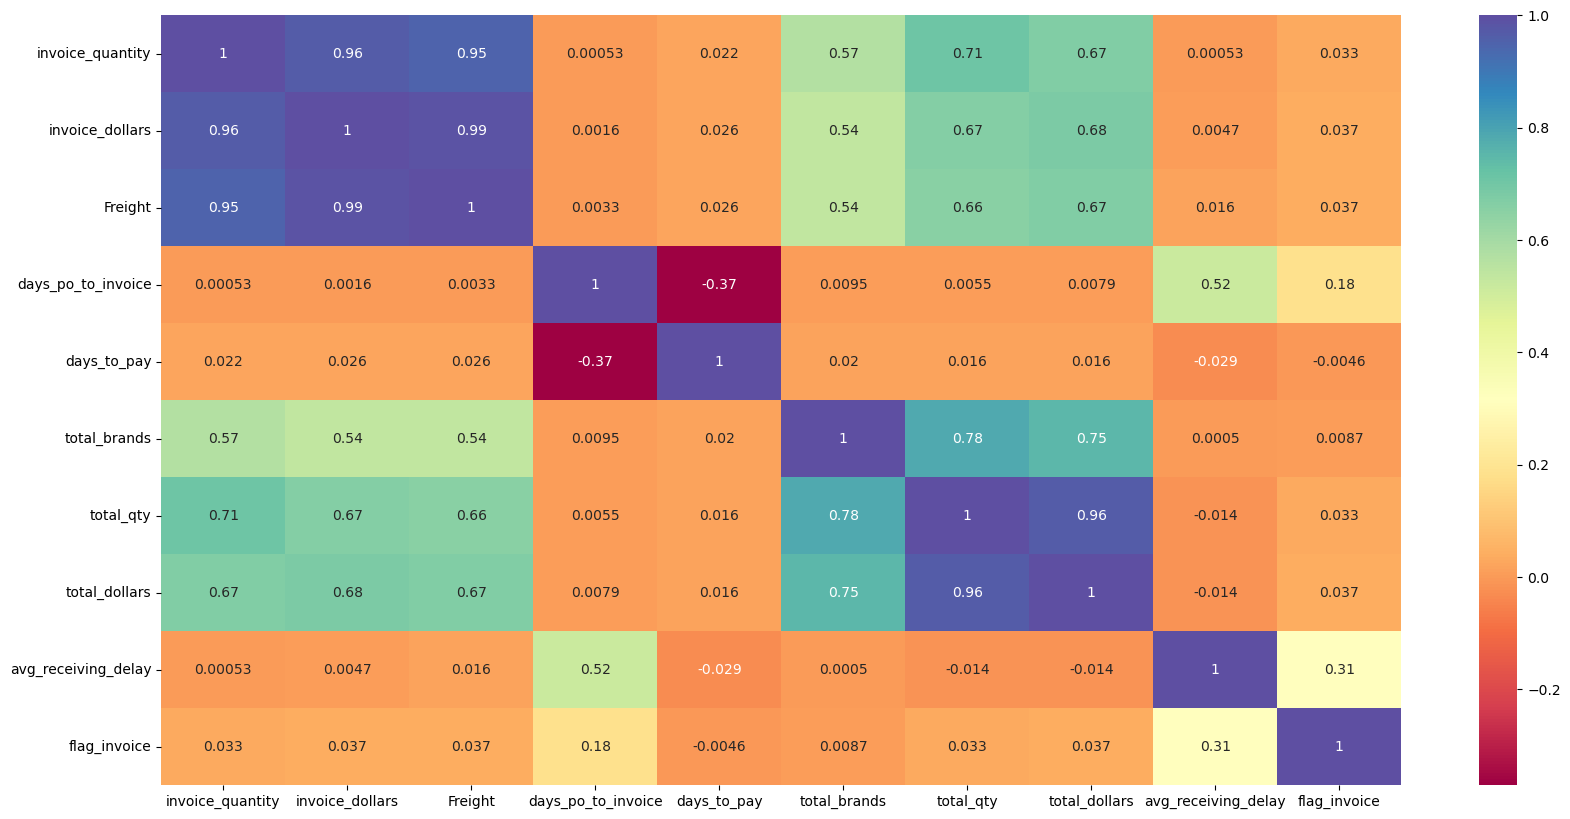

In [11]:
plt.figure(figsize=(20,10))
sns.heatmap(df.iloc[:,1:].corr(),annot=True,cmap='Spectral',)
plt.show()

In [12]:
df[df['flag_invoice']==0]['invoice_quantity'].mean()

np.float64(5726.4722598105545)

In [13]:
df.columns

Index(['PONumber', 'invoice_quantity', 'invoice_dollars', 'Freight',
       'days_po_to_invoice', 'days_to_pay', 'total_brands', 'total_qty',
       'total_dollars', 'avg_receiving_delay', 'flag_invoice'],
      dtype='object')

In [14]:
flagged=df[df['flag_invoice']==1]
normal=df[df['flag_invoice']==0]

features=['invoice_quantity', 'invoice_dollars', 'Freight',
       'days_po_to_invoice', 'days_to_pay', 'total_brands', 'total_qty',
       'total_dollars', 'avg_receiving_delay']
results=[]
non_signficant_features=[]
for feature in features:
    flagged_mean=flagged[feature].mean()
    normal_mean=normal[feature].mean()

    tstat,p_val=ttest_ind(flagged[feature],normal[feature],equal_var=False)

    if(p_val<0.05):
        results.append({
        'feature':feature,
        'flagged_mean':flagged_mean.round(2),
        'normal_mean':normal_mean.round(2),
        'p-value':p_val.round(3)
        })
    else:
        non_signficant_features.append(feature)
    
    

In [15]:
pd.DataFrame(results)

,feature,flagged_mean,normal_mean,p-value
0,invoice_quantity,6723.52,5726.47,0.022
1,invoice_dollars,65506.23,54355.95,0.009
2,Freight,333.51,277.17,0.009
3,days_po_to_invoice,17.23,16.02,0.000
4,total_qty,6723.52,5726.47,0.022
5,total_dollars,65506.23,54355.95,0.009
6,avg_receiving_delay,8.47,7.27,0.000


In [16]:
non_signficant_features

['days_to_pay', 'total_brands']

In [17]:
def get_performance_measure(model,predictor,target,model_name):
    y_pred=model.predict(predictor)
    accuracy=accuracy_score(target,y_pred)
    recall=recall_score(target,y_pred)
    f1=f1_score(target,y_pred)
    precision=precision_score(target,y_pred)
    print(f"\n{model_name}")
    #df_score=pd.DataFrame({'Accuracy':accuracy,'Recall':recall,'F1_score':f1,'Precision':precision},index=[0])
    #display(df_score)
    print(f"Accuracy score : {accuracy}")
    report=classification_report(target,y_pred)
    print(f"Classification report: \n{report}")

In [18]:
df.columns

Index(['PONumber', 'invoice_quantity', 'invoice_dollars', 'Freight',
       'days_po_to_invoice', 'days_to_pay', 'total_brands', 'total_qty',
       'total_dollars', 'avg_receiving_delay', 'flag_invoice'],
      dtype='object')

In [19]:
X=df[['invoice_quantity', 'invoice_dollars', 'Freight','total_brands',
       'days_po_to_invoice', 'total_qty',
       'total_dollars']]
y=df['flag_invoice']


X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [20]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,total_brands,days_po_to_invoice,total_qty,total_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,41.0,16.0,6059.0,58073.0
std,14453.0,140234.0,714.0,77.0,3.0,14453.0,140234.0
min,1.0,4.0,0.0,1.0,9.0,1.0,4.0
25%,83.0,968.0,5.0,3.0,14.0,83.0,968.0
50%,423.0,4765.0,25.0,7.0,16.0,423.0,4765.0
75%,5100.0,44587.0,230.0,46.0,19.0,5100.0,44587.0
max,141660.0,1660436.0,8468.0,807.0,23.0,141660.0,1660436.0


In [21]:
model1=LogisticRegression(random_state=42)
model1.fit(X_train_scaled,y_train)

model2=DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled,y_train)

model3=RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled,y_train)

model4=BaggingClassifier(random_state=42)
model4.fit(X_train_scaled,y_train)

model5=AdaBoostClassifier(random_state=42)
model5.fit(X_train_scaled,y_train)

model6=GradientBoostingClassifier(random_state=42)
model6.fit(X_train_scaled,y_train)

model7=XGBClassifier(random_state=42)
model7.fit(X_train_scaled,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [22]:
print("Training performance\n")
get_performance_measure(model1,X_train_scaled,y_train,'LogisticRegression')
get_performance_measure(model2,X_train_scaled,y_train,'DecisionTreeClassifier')
get_performance_measure(model3,X_train_scaled,y_train,'RandomForestClassifier')
get_performance_measure(model4,X_train_scaled,y_train,'BaggingClassifier')
get_performance_measure(model5,X_train_scaled,y_train,'AdaBoostClassifier')
get_performance_measure(model6,X_train_scaled,y_train,'GradientBoostingClassifier')
get_performance_measure(model7,X_train_scaled,y_train,'XGBClassifier')

Training performance


LogisticRegression
Accuracy score : 0.6813261163734776
Classification report: 
              precision    recall  f1-score   support

           0       0.68      0.99      0.81      2970
           1       0.69      0.06      0.12      1464

    accuracy                           0.68      4434
   macro avg       0.69      0.52      0.46      4434
weighted avg       0.68      0.68      0.58      4434


DecisionTreeClassifier
Accuracy score : 0.9997744700045106
Classification report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2970
           1       1.00      1.00      1.00      1464

    accuracy                           1.00      4434
   macro avg       1.00      1.00      1.00      4434
weighted avg       1.00      1.00      1.00      4434


RandomForestClassifier
Accuracy score : 0.9997744700045106
Classification report: 
              precision    recall  f1-score   support

           0       1.

In [23]:
print("Testing performance\n")
get_performance_measure(model1,X_test_scaled,y_test,'LogisticRegression')
get_performance_measure(model2,X_test_scaled,y_test,'DecisionTreeClassifier')
get_performance_measure(model3,X_test_scaled,y_test,'RandomForestClassifier')
get_performance_measure(model4,X_test_scaled,y_test,'BaggingClassifier')
get_performance_measure(model5,X_test_scaled,y_test,'AdaBoostClassifier')
get_performance_measure(model6,X_test_scaled,y_test,'GradientBoostingClassifier')
get_performance_measure(model7,X_test_scaled,y_test,'XGBClassifier')

Testing performance


LogisticRegression
Accuracy score : 0.6591523895401262
Classification report: 
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.57      0.06      0.11       384

    accuracy                           0.66      1109
   macro avg       0.62      0.52      0.45      1109
weighted avg       0.63      0.66      0.55      1109


DecisionTreeClassifier
Accuracy score : 0.8097385031559964
Classification report: 
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       725
           1       0.75      0.67      0.71       384

    accuracy                           0.81      1109
   macro avg       0.79      0.78      0.78      1109
weighted avg       0.81      0.81      0.81      1109


RandomForestClassifier
Accuracy score : 0.8764652840396754
Classification report: 
              precision    recall  f1-score   support

           0       0.8

In [24]:
X_train.columns

Index(['invoice_quantity', 'invoice_dollars', 'Freight', 'total_brands',
       'days_po_to_invoice', 'total_qty', 'total_dollars'],
      dtype='object')

In [25]:
pd.Series(model7.feature_importances_,index=X_train.columns).sort_values(ascending=False)

total_dollars         0.345414
invoice_quantity      0.144171
invoice_dollars       0.135449
total_qty             0.134187
days_po_to_invoice    0.112340
Freight               0.073755
total_brands          0.054684
dtype: float32

In [26]:
X=df[['invoice_quantity', 'invoice_dollars',
       'days_po_to_invoice', 'total_qty',
       'total_dollars']]
y=df['flag_invoice']


X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [27]:
model1=LogisticRegression(random_state=42)
model1.fit(X_train_scaled,y_train)

model2=DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled,y_train)

model3=RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled,y_train)

model4=BaggingClassifier(random_state=42)
model4.fit(X_train_scaled,y_train)

model5=AdaBoostClassifier(random_state=42)
model5.fit(X_train_scaled,y_train)

model6=GradientBoostingClassifier(random_state=42)
model6.fit(X_train_scaled,y_train)

model7=XGBClassifier(random_state=42)
model7.fit(X_train_scaled,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [28]:
print("Training performance\n")
get_performance_measure(model1,X_train_scaled,y_train,'LogisticRegression')
get_performance_measure(model2,X_train_scaled,y_train,'DecisionTreeClassifier')
get_performance_measure(model3,X_train_scaled,y_train,'RandomForestClassifier')
get_performance_measure(model4,X_train_scaled,y_train,'BaggingClassifier')
get_performance_measure(model5,X_train_scaled,y_train,'AdaBoostClassifier')
get_performance_measure(model6,X_train_scaled,y_train,'GradientBoostingClassifier')
get_performance_measure(model7,X_train_scaled,y_train,'XGBClassifier')

Training performance


LogisticRegression
Accuracy score : 0.6820027063599459
Classification report: 
              precision    recall  f1-score   support

           0       0.68      0.99      0.81      2970
           1       0.70      0.06      0.12      1464

    accuracy                           0.68      4434
   macro avg       0.69      0.53      0.46      4434
weighted avg       0.69      0.68      0.58      4434


DecisionTreeClassifier
Accuracy score : 0.998872350022553
Classification report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2970
           1       1.00      1.00      1.00      1464

    accuracy                           1.00      4434
   macro avg       1.00      1.00      1.00      4434
weighted avg       1.00      1.00      1.00      4434


RandomForestClassifier
Accuracy score : 0.998872350022553
Classification report: 
              precision    recall  f1-score   support

           0       1.00

In [29]:
print("Testing performance\n")
get_performance_measure(model1,X_test_scaled,y_test,'LogisticRegression')
get_performance_measure(model2,X_test_scaled,y_test,'DecisionTreeClassifier')
get_performance_measure(model3,X_test_scaled,y_test,'RandomForestClassifier')
get_performance_measure(model4,X_test_scaled,y_test,'BaggingClassifier')
get_performance_measure(model5,X_test_scaled,y_test,'AdaBoostClassifier')
get_performance_measure(model6,X_test_scaled,y_test,'GradientBoostingClassifier')
get_performance_measure(model7,X_test_scaled,y_test,'XGBClassifier')

Testing performance


LogisticRegression
Accuracy score : 0.6591523895401262
Classification report: 
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.58      0.05      0.10       384

    accuracy                           0.66      1109
   macro avg       0.62      0.52      0.44      1109
weighted avg       0.63      0.66      0.55      1109


DecisionTreeClassifier
Accuracy score : 0.8259693417493237
Classification report: 
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       725
           1       0.77      0.71      0.74       384

    accuracy                           0.83      1109
   macro avg       0.81      0.80      0.80      1109
weighted avg       0.82      0.83      0.82      1109


RandomForestClassifier
Accuracy score : 0.8791704238052299
Classification report: 
              precision    recall  f1-score   support

           0       0.8

In [30]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
model=XGBClassifier(random_state=42,eval_metric='logloss')
parameters = {
    "max_depth": np.arange(4,6,1),
    "n_estimators": np.arange(150,300,50),
    "subsample":[0.5,0.7,0.9,1],
    "learning_rate":[0.01,0.1,0.2,0.05],
    "gamma":[0,1,3],
    "colsample_bytree":[0.5,0.7,0.9,1],
    "colsample_bylevel":[0.5,0.7,0.9,1]
}
random_obj=RandomizedSearchCV(model,parameters,scoring='recall',cv=5,n_iter=200,n_jobs=-1,verbose=2)
random_obj.fit(X_train_scaled,y_train)

xgb_tuned=random_obj.best_estimator_
xgb_tuned.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.9, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=np.int64(5), max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(250), n_jobs=None,
              num_parallel_tree=None, ...)

In [31]:
get_performance_measure(xgb_tuned,X_train_scaled,y_train,'XGB_tuned_training')


XGB_tuned_training
Accuracy score : 0.9429409111411817
Classification report: 
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      2970
           1       0.99      0.83      0.91      1464

    accuracy                           0.94      4434
   macro avg       0.96      0.92      0.93      4434
weighted avg       0.95      0.94      0.94      4434



In [32]:
get_performance_measure(xgb_tuned,X_test_scaled,y_test,'XGB_tuned_testing')


XGB_tuned_testing
Accuracy score : 0.8917944093778178
Classification report: 
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       725
           1       0.95      0.72      0.82       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.89      1109



In [34]:
X_train.columns

Index(['invoice_quantity', 'invoice_dollars', 'days_po_to_invoice',
       'total_qty', 'total_dollars'],
      dtype='object')

[CV] END colsample_bylevel=0.5, colsample_bytree=1, gamma=0, learning_rate=0.2, max_depth=4, n_estimators=200, subsample=0.9; total time=   0.0s
[CV] END colsample_bylevel=1, colsample_bytree=0.7, gamma=1, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.9; total time=   0.0s
[CV] END colsample_bylevel=0.9, colsample_bytree=0.9, gamma=3, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.9; total time=   0.0s
[CV] END colsample_bylevel=0.7, colsample_bytree=0.5, gamma=0, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=1; total time=   0.0s
[CV] END colsample_bylevel=0.7, colsample_bytree=0.9, gamma=1, learning_rate=0.1, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bylevel=0.5, colsample_bytree=0.5, gamma=0, learning_rate=0.05, max_depth=4, n_estimators=150, subsample=1; total time=   0.0s
[CV] END colsample_bylevel=0.5, colsample_bytree=0.5, gamma=1, learning_rate=0.2, max_depth=5, n_estimators=250, subsample

Exception ignored in: <function ResourceTracker.__del__ at 0x104279b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107f49b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106125b20>
Traceback (most recent call last

[CV] END colsample_bylevel=0.7, colsample_bytree=1, gamma=1, learning_rate=0.2, max_depth=4, n_estimators=150, subsample=1; total time=   0.0s
[CV] END colsample_bylevel=0.9, colsample_bytree=1, gamma=3, learning_rate=0.2, max_depth=4, n_estimators=250, subsample=1; total time=   0.0s
[CV] END colsample_bylevel=0.9, colsample_bytree=1, gamma=3, learning_rate=0.2, max_depth=4, n_estimators=250, subsample=1; total time=   0.0s
[CV] END colsample_bylevel=0.5, colsample_bytree=0.5, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=150, subsample=1; total time=   0.0s
[CV] END colsample_bylevel=0.9, colsample_bytree=0.5, gamma=1, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=1; total time=   0.0s
[CV] END colsample_bylevel=0.9, colsample_bytree=0.9, gamma=3, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.9; total time=   0.0s
[CV] END colsample_bylevel=0.5, colsample_bytree=0.7, gamma=0, learning_rate=0.2, max_depth=5, n_estimators=150, subsample=1; total 

Exception ignored in: <function ResourceTracker.__del__ at 0x11041db20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106f59b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105865b20>
Traceback (most recent call last

[CV] END colsample_bylevel=0.5, colsample_bytree=1, gamma=0, learning_rate=0.2, max_depth=4, n_estimators=200, subsample=0.9; total time=   0.0s
[CV] END colsample_bylevel=0.9, colsample_bytree=1, gamma=3, learning_rate=0.2, max_depth=4, n_estimators=250, subsample=1; total time=   0.0s
[CV] END colsample_bylevel=0.9, colsample_bytree=1, gamma=3, learning_rate=0.2, max_depth=4, n_estimators=250, subsample=1; total time=   0.0s
[CV] END colsample_bylevel=0.5, colsample_bytree=0.5, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=150, subsample=1; total time=   0.0s
[CV] END colsample_bylevel=0.9, colsample_bytree=0.5, gamma=1, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=1; total time=   0.0s
[CV] END colsample_bylevel=0.7, colsample_bytree=0.5, gamma=0, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=1; total time=   0.0s
[CV] END colsample_bylevel=0.5, colsample_bytree=0.7, gamma=1, learning_rate=0.2, max_depth=4, n_estimators=150, subsample=1; total 

Exception ignored in: <function ResourceTracker.__del__ at 0x102f85b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10376db20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1057bdb20>
Traceback (most recent call last

[CV] END colsample_bylevel=0.5, colsample_bytree=1, gamma=0, learning_rate=0.2, max_depth=4, n_estimators=200, subsample=0.9; total time=   0.0s
[CV] END colsample_bylevel=1, colsample_bytree=0.7, gamma=1, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.9; total time=   0.0s
[CV] END colsample_bylevel=0.7, colsample_bytree=0.5, gamma=0, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=1; total time=   0.0s
[CV] END colsample_bylevel=0.7, colsample_bytree=0.9, gamma=1, learning_rate=0.1, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bylevel=0.5, colsample_bytree=0.5, gamma=0, learning_rate=0.05, max_depth=4, n_estimators=150, subsample=1; total time=   0.0s
[CV] END colsample_bylevel=0.5, colsample_bytree=0.5, gamma=1, learning_rate=0.2, max_depth=5, n_estimators=250, subsample=0.5; total time=   0.1s
[CV] END colsample_bylevel=0.5, colsample_bytree=0.5, gamma=1, learning_rate=0.2, max_depth=5, n_estimators=250, subsample=

Exception ignored in: <function ResourceTracker.__del__ at 0x104a81b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
